In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn as sl
import matplotlib.pyplot as plt

In [8]:
data = pd.read_csv('Rejestr_Produktow_Leczniczych_calosciowy_stan_na_dzien_20250425.csv', sep=";")

In [9]:
col = data.columns
col1 = col[0:8]
col2 = col[8:17]
col3 = col[17:25]
col4 = col[25:33]

In [10]:
data = data.drop(columns=["Ulotka", "Charakterystyka", "Etykieto-ulotka", "Ulotka importu równoległego",
                          "Etykieto-ulotka importu równoległego", "Oznakowanie opakowań importu równoległego",
                          "Materiały edukacyjne dla osoby wykonującej zawód medyczny", "Materiały edukacyjne dla pacjenta"])

In [11]:
data = data.replace('-', np.nan)

In [12]:
data_null = pd.DataFrame({"Sum": data.isnull().sum(), "Avg": data.isnull().mean()})
data_null["Procent"] = round(data_null["Avg"]*100, 2)
data_null

,Sum,Avg,Procent
Identyfikator Produktu Leczniczego,0,0.000000,0.00
Nazwa Produktu Leczniczego,0,0.000000,0.00
Nazwa powszechnie stosowana,19,0.000852,0.09
Rodzaj preparatu,0,0.000000,0.00
Zakaz stosowania u zwierząt,22146,0.992872,99.29
Nazwa poprzednia produktu,21000,0.941493,94.15
Droga podania - Gatunek - Tkanka - Okres karencji,57,0.002555,0.26
Moc,876,0.039274,3.93
Postać farmaceutyczna,0,0.000000,0.00
Typ procedury,0,0.000000,0.00


In [13]:
len(data['Nazwa Produktu Leczniczego'].unique())

11213

In [17]:
top15 = data['Nazwa Produktu Leczniczego'].value_counts().nlargest(15).index
top15_x = data[data['Nazwa Produktu Leczniczego'].isin(top15)]['Nazwa Produktu Leczniczego']

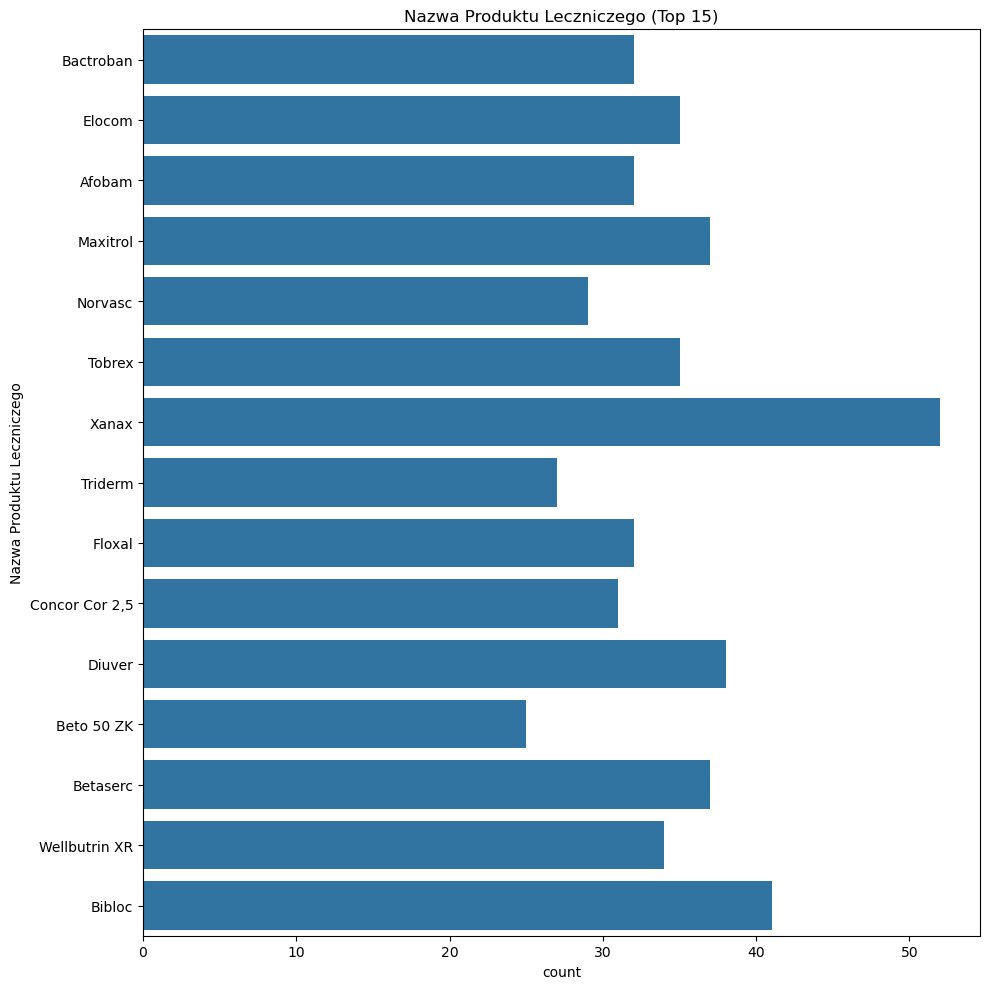

In [22]:
fig, ax = plt.subplots(figsize=(10, 10), facecolor='white')
sns.countplot(data=top15_x, ax=ax)

plt.title('Nazwa Produktu Leczniczego (Top 15)')

plt.tight_layout()
plt.show()

In [34]:
topInne = data['Nazwa Produktu Leczniczego'].where(data['Nazwa Produktu Leczniczego'].isin(top15), 'Inne')

In [35]:
# len(data['Nazwa Produktu Leczniczego'] == )
int(np.sum(topInne == 'Inne'))

21788

In [33]:
fig.savefig('NazwaProduktuLeczniczego(Top15).png')